In [1]:
# -*- coding: utf-8 -*-
"""
DataAn Enhanced — полный автоматический статистический анализ с HTML-отчётом
"""
import sys, gc, io, os, base64, warnings
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple
from itertools import combinations
from scipy import stats as sp_stats
from scipy.stats import chi2_contingency, fisher_exact, shapiro, levene, kruskal
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, r2_score, mean_squared_error)
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.multivariate.manova import MANOVA
try:
    import xgboost as xgb
    _XGB_AVAILABLE = True
except ImportError:
    _XGB_AVAILABLE = False

# Импортируем расширенный класс
from analyzer_enhanced import DataAnalyzer, create_interactive_file_uploader

# Инициализация виджета загрузки
get_uploaded_data, get_file_name = create_interactive_file_uploader()


🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА ДАННЫХ

📌 Предварительная обработка...
    Очищенные данные: 2500 строк, 10 столбцов

📊 1. Визуализации:
    1.1 Скрипичная диаграмма + диаграмма роя...


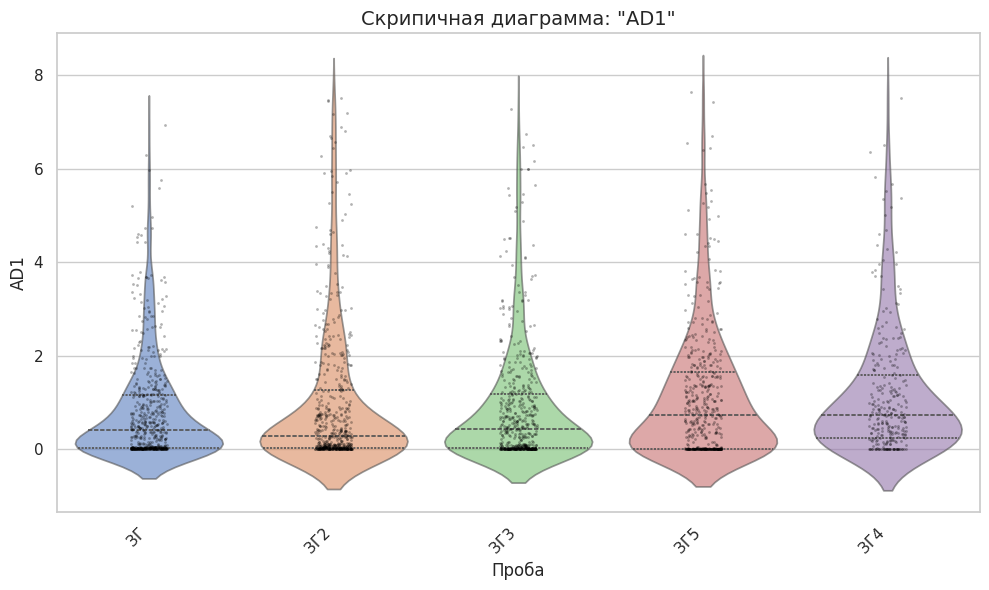

    1.2 Ящик с усами (boxplot)...


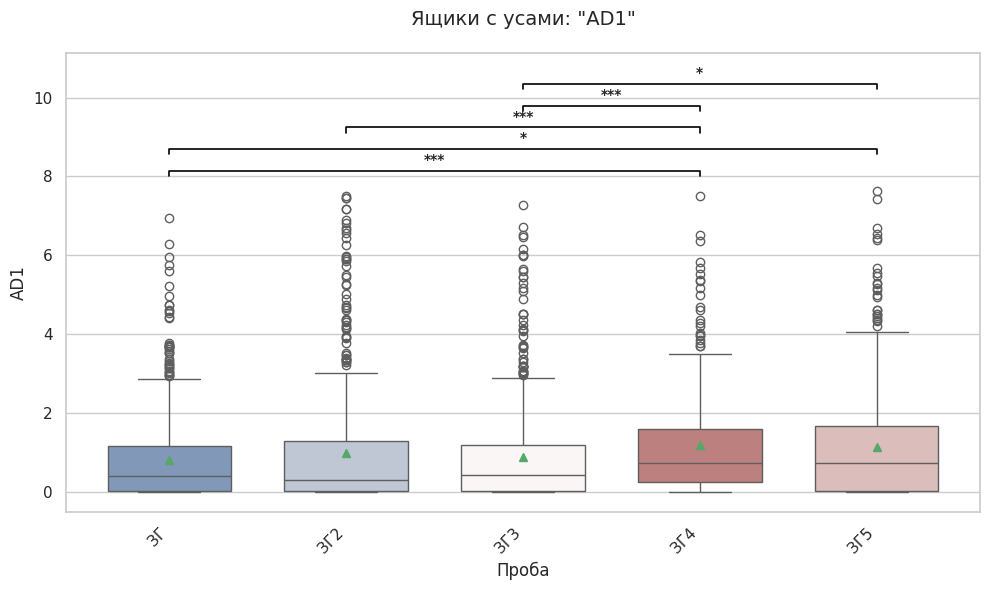

    1.3 Гистограммы...


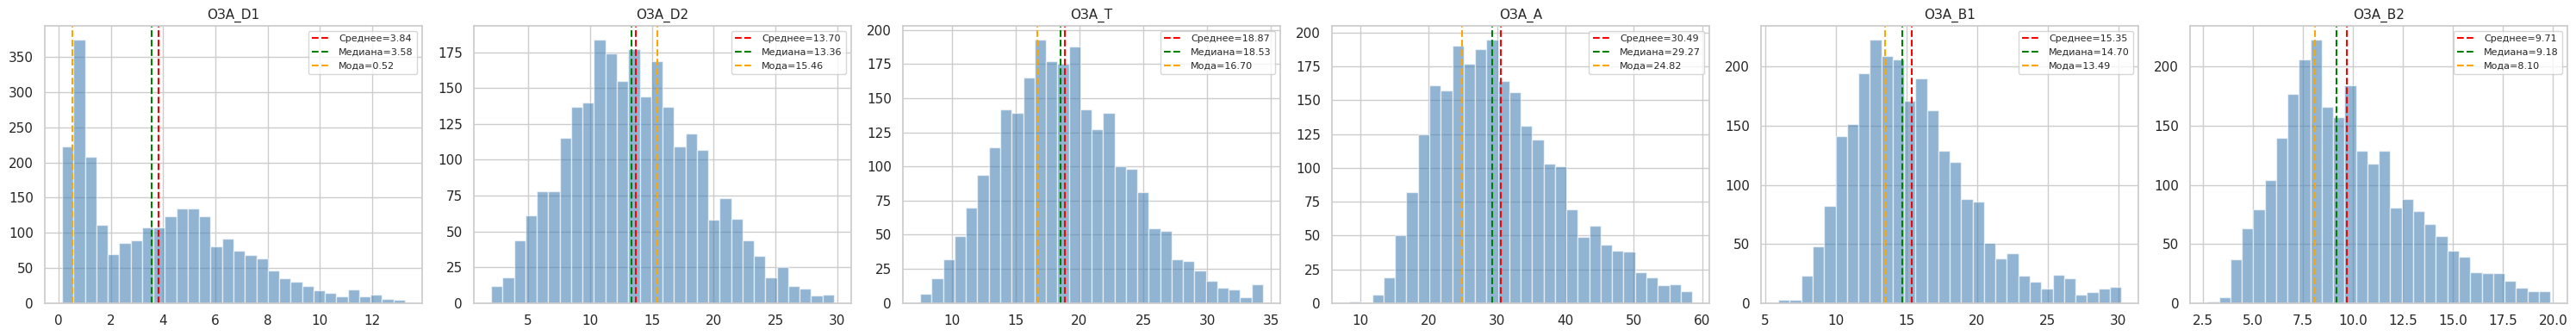

    1.4 Круговая диаграмма...


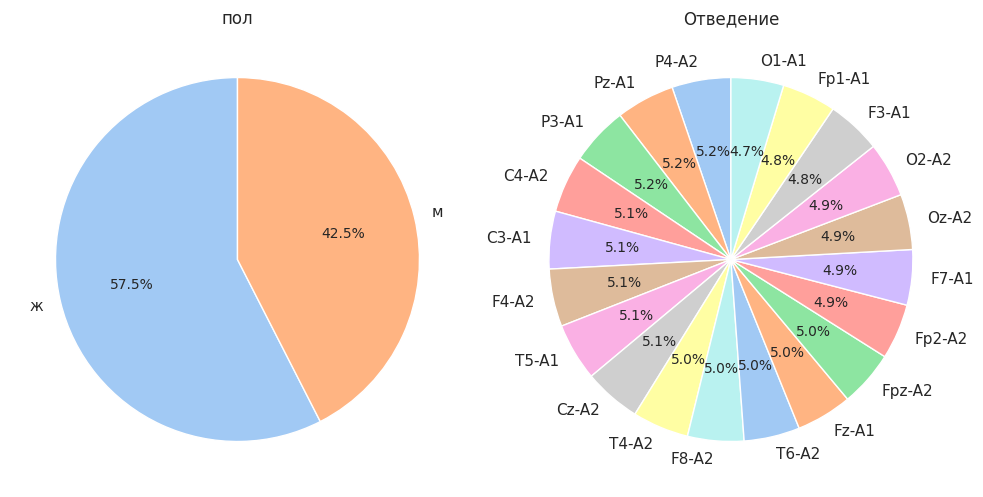

    1.5 Точечная диаграмма с линией регрессии...


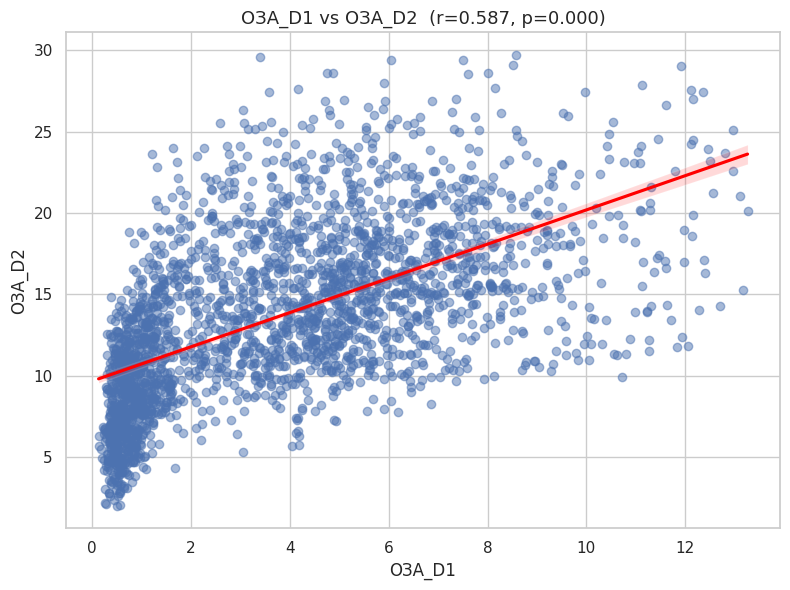

    1.6 Парная сетка (pair grid)...


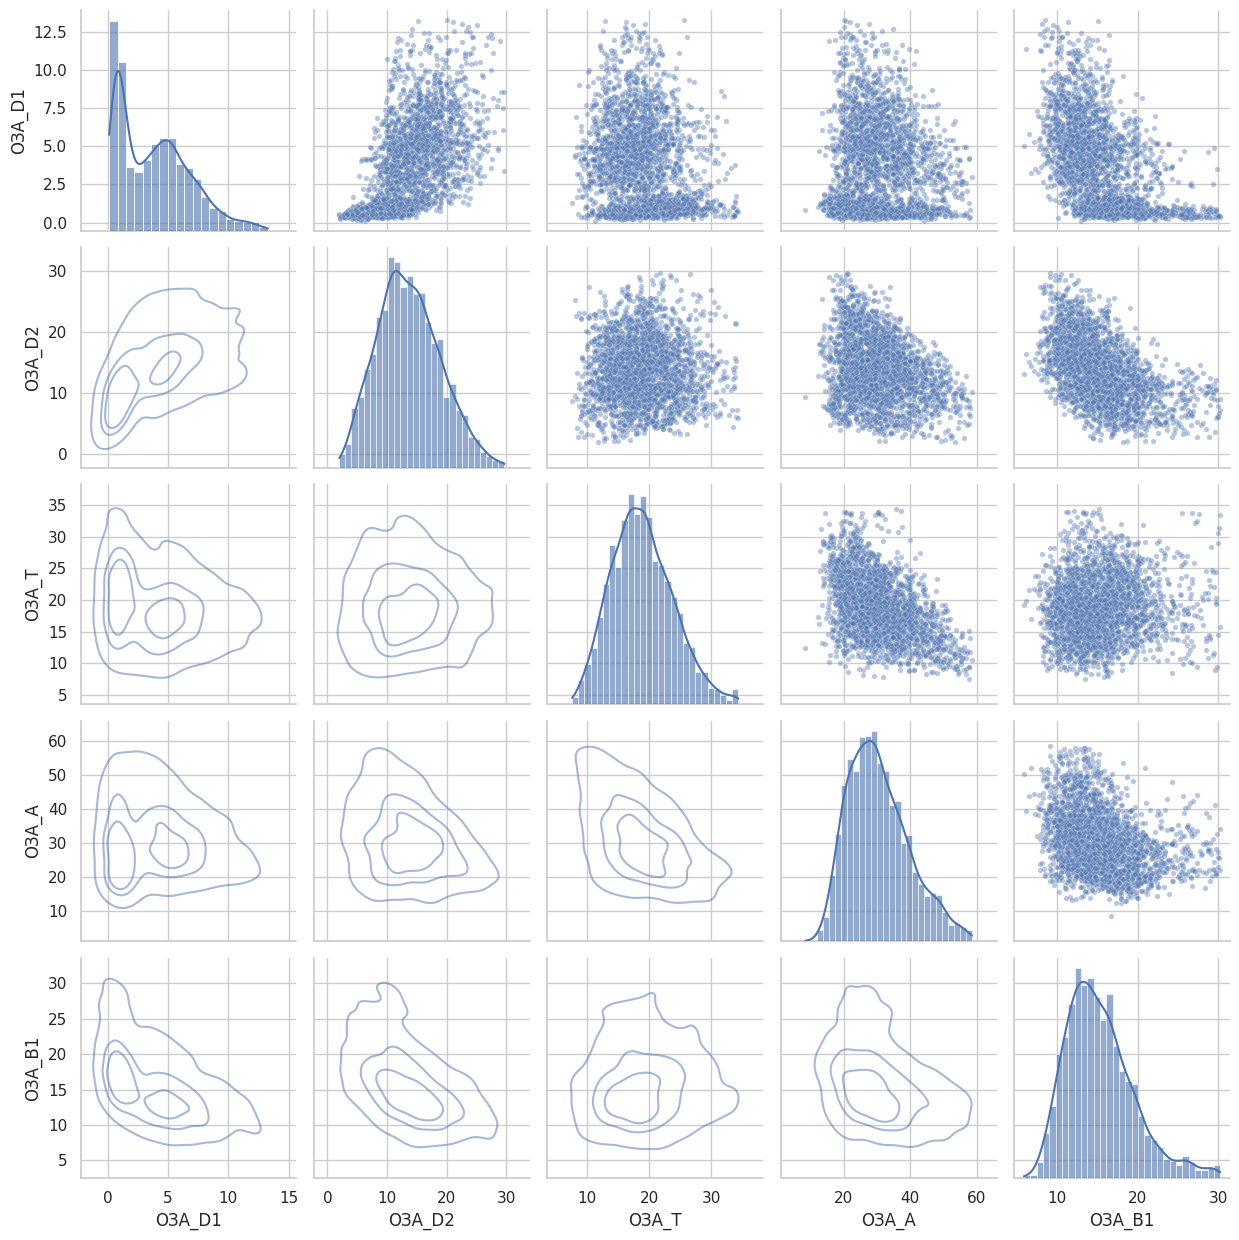

    1.7 Матрица корреляций...


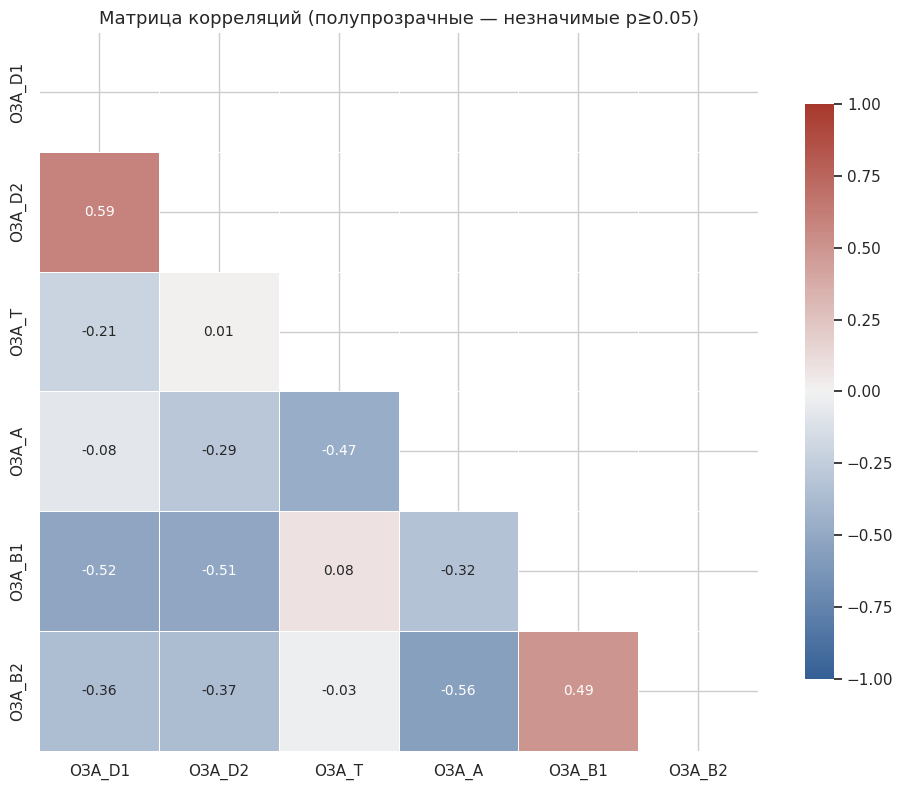


📊 2. ANOVA / критерий Крускала — Уоллиса:
Проверка предпосылок:
  Нормальность (Shapiro-Wilk): Нет
  Гомогенность дисперсии (Levene): Нет

Kruskal-Wallis: H=24.408, p=0.0001
Интерпретация: статистически значимо (alpha = 0.05).


📊 3. Постхок‑тест Тьюки:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    ЗГ    ЗГ2   0.1676 0.2007 -0.0455 0.3807  False
    ЗГ    ЗГ3   0.0682 0.9076 -0.1456  0.282  False
    ЗГ    ЗГ4    0.367 0.0012   0.106 0.6279   True
    ЗГ    ЗГ5   0.3136 0.0011  0.0913 0.5358   True
   ЗГ2    ЗГ3  -0.0994 0.7163 -0.3149 0.1161  False
   ЗГ2    ЗГ4   0.1994 0.2316  -0.063 0.4617  False
   ЗГ2    ЗГ5    0.146 0.3855 -0.0779 0.3699  False
   ЗГ3    ЗГ4   0.2988 0.0166  0.0359 0.5617   True
   ЗГ3    ЗГ5   0.2454  0.024  0.0209 0.4699   True
   ЗГ4    ЗГ5  -0.0534 0.9832 -0.3232 0.2165  False
---------------------------------------------------

📊 4. Двухфакторн

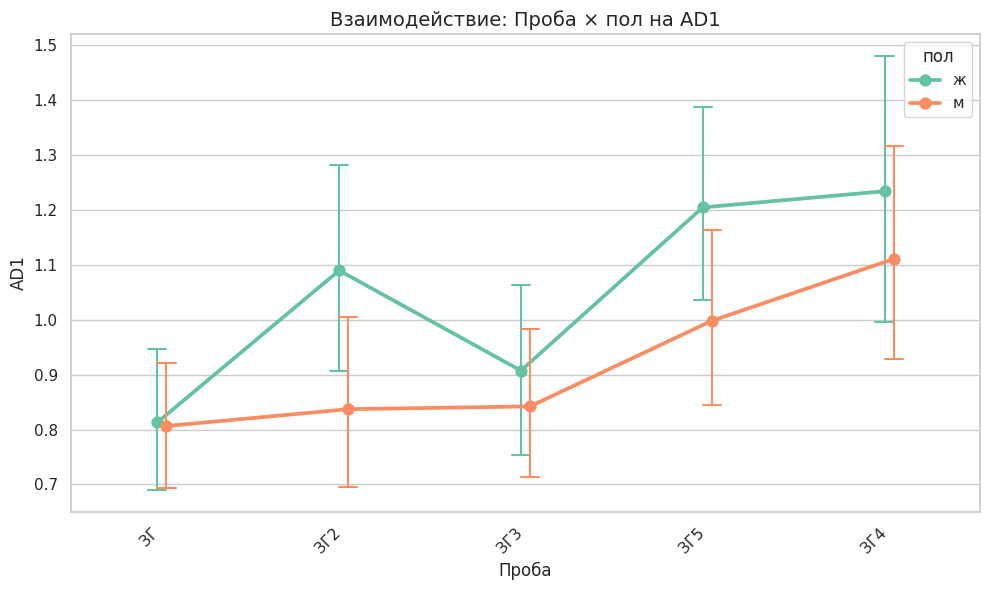


📊 5. Анализ категориальных данных:
Ни одна из 3 пар не связана (p > 0.05).

📊 6. Многомерный дисперсионный анализ (MANOVA):
MANOVA: 7 зависимых, 3 факторов.
Минимальный p = 0.0000


📊 7. Постхок‑анализ для MANOVA:
Значимых различий: 29

📊 8. Сравнение между выборками:
Групп: 1

📊 9. Линейная регрессия:
R²=0.559, RMSE=0.901
   Диагностика модели:


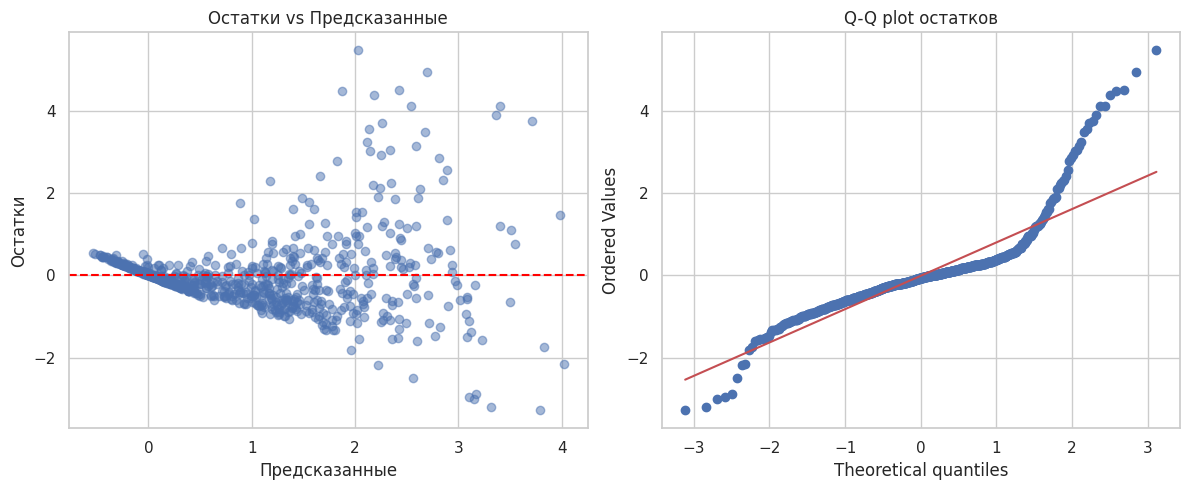


📊 10. Отбор признаков:
   Важность признаков по случайному лесу (RF):

   Рекурсивное исключение признаков (RFE):
Отбрано: 3
   Метод главных компонент (PCA):
Компонент для 95%: 5

📊 11. Кластерный анализ:
   Метод локтя (подбор оптимального числа кластеров):
Оптимально k=2
   Кластеризация методом K‑средних (K‑means):
k=2
   ANOVA для кластеров:

   Файл XLSX сохранён: /home/ad/Yandex.Disk/Python/IPytn/DataAnalys/Aromaterapia10_dannye_EEG_with_clusters.xlsx

🤖 12. Машинное обучение:


📄 Настройка HTML‑отчёта...


HTML(value='<b>Выберите разделы для отчёта:</b>')

In [3]:
# -*- coding: utf-8 -*-
"""
ЯЧЕЙКА 2: Полный цикл анализа и генерация HTML-отчёта.
"""
try:
    uploaded_df = get_uploaded_data()
    uploaded_file_name = get_file_name()
    if uploaded_df is None:
        raise ValueError("Файл не загружен. Используйте виджет в Ячейке 1.")

    if 'analyzer' not in globals():
        analyzer = DataAnalyzer(uploaded_df, file_name=uploaded_file_name)
        analyzer.create_parameter_selector()
        print("⚠️ Выберите параметры в виджетах выше и запустите эту ячейку ЕЩЁ РАЗ.")
    else:
        import ipywidgets as widgets
        from IPython.display import display, clear_output, HTML, FileLink
    
        print('='*60)
        print('🚀 ЗАПУСК ПОЛНОГО АНАЛИЗА ДАННЫХ')
        import ipywidgets as widgets
        from IPython.display import display, clear_output, HTML, FileLink
        print('='*60)

        # --- ПРЕДОБРАБОТКА ---
        print('\n📌 Предварительная обработка...')
        df_clean = analyzer.preprocess(remove_outliers=True, z_threshold=3.0, balance_groups=True)
        analyzer._current_df = df_clean
        print(f'    Очищенные данные: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов')
        
        # --- 1. ВИЗУАЛИЗАЦИЯ ---
        print('\n📊 1. Визуализации:')
        print('    1.1 Скрипичная диаграмма + диаграмма роя...')
        analyzer.plot_violin()
        print('    1.2 Ящик с усами (boxplot)...')
        analyzer.plot_boxplot_with_significance()
        print('    1.3 Гистограммы...')
        analyzer.plot_histograms()
        print('    1.4 Круговая диаграмма...')
        analyzer.plot_pie_chart()
        print('    1.5 Точечная диаграмма с линией регрессии...')
        analyzer.plot_scatter_with_regression()
        print('    1.6 Парная сетка (pair grid)...')
        analyzer.plot_pairgrid()
        print('    1.7 Матрица корреляций...')
        analyzer.plot_correlation_matrix()
        
        # --- 2. СТАТИСТИЧЕСКИЙ АНАЛИЗ ---
        print('\n📊 2. ANOVA / критерий Крускала — Уоллиса:')
        print(analyzer.perform_anova_analysis())
        
        print('\n📊 3. Постхок‑тест Тьюки:')
        print(analyzer.perform_posthoc_tukey())
        
        print('\n📊 4. Двухфакторный дисперсионный анализ (Two‑way ANOVA):')
        print(analyzer.perform_two_way_anova())
        print('   График взаимодействия факторов:')
        analyzer.plot_interaction_effect()
        
        print('\n📊 5. Анализ категориальных данных:')
        print(analyzer.perform_categorical_analysis())
        
        print('\n📊 6. Многомерный дисперсионный анализ (MANOVA):')
        print(analyzer.perform_manova())
        
        print('\n📊 7. Постхок‑анализ для MANOVA:')
        print(analyzer.perform_posthoc_manova())
        
        # --- 3. РЕГРЕССИОННЫЙ АНАЛИЗ ---
        print('\n📊 8. Регрессионный анализ:')
        print(analyzer.perform_linear_regression())
        print('   Диагностика модели:')
        analyzer.plot_regression_diagnostics()
        analyzer.perform_logistic_regression_cat()
        
        # --- 4. ОТБОР ПРИЗНАКОВ ---
        print('\n📊 9. Отбор признаков:')
        print('   Важность признаков по случайному лесу (RF):')
        print(analyzer.feature_selection_rf())
        print('   Рекурсивное исключение признаков (RFE):')
        print(analyzer.rfe_selection())
        print('   Метод главных компонент (PCA):')
        print(analyzer.pca_analysis())
        
        # --- 5. КЛАСТЕРНЫЙ АНАЛИЗ ---
        print('\n📊 10. Кластерный анализ:')
        print('   Метод локтя (подбор оптимального числа кластеров):')
        print(analyzer.determine_optimal_clusters(max_k=10))
        print('   Кластеризация методом K‑средних (K‑means):')
        print(analyzer.perform_kmeans())
        print('   ANOVA для кластеров:')
        print(analyzer.anova_for_clusters())
        cluster_xlsx = analyzer.save_clusters_to_xlsx()
        if cluster_xlsx:
            print(f'   Файл XLSX сохранён: {cluster_xlsx}')
        
        # --- 11. МАШИННОЕ ОБУЧЕНИЕ ---
        print('\n🤖 11. Машинное обучение:')
        analyzer.ml_benchmark(df_clean)
        
        print("\n" + "="*60)
        
        # --- НАСТРОЙКА HTML‑ОТЧЁТА ---
        print("\n📄 Настройка HTML‑отчёта...")
        analyzer.create_comment_widgets()

        sec_keys = [
            'plots', 'anova', 'manova',
            'linear_regression', 'feature_selection', 'pca',
            'cluster', 'ml',
        ]
        sec_labels = [
            'Визуализация (Violin, Boxplot, Гистограммы и др.)',
            'ANOVA / Kruskal-Wallis / Категориальные',
            'MANOVA / Post-hoc MANOVA',
            'Линейная регрессия',
            'Отбор признаков (RF, RFE)',
            'Метод главных компонент (PCA)',
            'Кластерный анализ',
            'Машинное обучение',
        ]

        cb_widgets = []
        display(widgets.HTML('<b>Выберите разделы для отчёта:</b>'))
        for k, lab in zip(sec_keys, sec_labels):
            cb = widgets.Checkbox(value=True, description=lab, indent=False, layout=widgets.Layout(width='320px'))
            cb_widgets.append(cb)
        display(widgets.VBox(cb_widgets))

        btn_gen = widgets.Button(
            description='📄 Сгенерировать HTML',
            button_style='success',
            layout=widgets.Layout(width='180px')
        )
        btn_reset = widgets.Button(
            description='🔄 Выбрать другие параметры',
            button_style='warning',
            layout=widgets.Layout(width='220px')
        )
        btn_open = widgets.Button(
            description='📂 Открыть HTML',
            button_style='info',
            layout=widgets.Layout(width='160px')
        )
        out_gen = widgets.Output()

        def on_gen(b):
            with out_gen:
                clear_output(wait=True)
                sel = {k: w.value for k, w in zip(sec_keys, cb_widgets)}
                analyzer.generate_html_report(df_clean, sections=sel)

        def on_reset(b):
            with out_gen:
                clear_output(wait=True)
            # Сброс: удаляем analyzer из globals, чтобы ячейка заново показала выбор параметров
            if 'analyzer' in globals():
                del globals()['analyzer']
            print('🔄 Параметры сброшены. Запустите ячейку снова для выбора новых параметров.')

        def on_open(b):
            with out_gen:
                clear_output(wait=True)
                import glob
                html_files = sorted(glob.glob('*_report.html'))
                if not html_files:
                    print('HTML-отчёт не найден. Сначала сгенерируйте его.')
                    return
                latest = html_files[-1]
                print(f'Открываю: {os.path.abspath(latest)}')
                import webbrowser
                webbrowser.open('file://' + os.path.abspath(latest))

        btn_gen.on_click(on_gen)
        btn_reset.on_click(on_reset)
        btn_open.on_click(on_open)

        hbox = widgets.HBox([btn_gen, btn_reset, btn_open])
        display(widgets.VBox([hbox, out_gen]))

except Exception as e:
    import traceback
    print(f'❌ Ошибка: {e}')
    traceback.print_exc()
